## 03 - Logistic Regression Baseline

Trains a logistic regression model as the linear baseline for transaction fraud detection.

`class_weight = "balanced"` handles the ~1.7% fraud imbalance. Primary metric: **PR-AUC** (preferred over ROC-AUC for imbalanced classes).

Results here set the bar for tree-based and ensemble models in later notebooks.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    classification_report, precision_recall_curve,
    PrecisionRecallDisplay, RocCurveDisplay
)
from pathlib import Path

In [46]:
data_dir = Path("../Data/Processed")
train = pd.read_csv(data_dir / "train_linear.csv")
test = pd.read_csv(data_dir / "test_linear.csv")

### Prepare Features & Target

In [47]:
FEATURE_COLS_LINEAR = [c for c in train.columns if c != "is_fraud"]
TARGET = "is_fraud"

x_train = train[FEATURE_COLS_LINEAR].fillna(0)
y_train = train[TARGET]
x_test = test[FEATURE_COLS_LINEAR].fillna(0)
y_test = test[TARGET]

In [48]:
print(f"Train: {len(train):,} rows | fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test: {len(test):,} rows | fraud rate: {y_test.mean()*100:.2f}%")

Train: 666,085 rows | fraud rate: 1.71%
Test: 333,915 rows | fraud rate: 1.71%


### Scale features

In [49]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Train model

class_weight = "balanced" tells sklearn to upweight fraud cases to compensate for the 1.71% imbalance

In [50]:
lr = LogisticRegression(class_weight = "balanced",
                        max_iter = 1000, random_state = 42,
                        C = 0.1)
lr.fit(x_train_scaled, y_train)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=42)

### Evaluate Model

In [51]:
y_proba = lr.predict_proba(x_test_scaled)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

pr_auc = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

In [52]:
print(f"LOGISTIC REGRESSION BASELINE")
print(f"PR_AUC: {pr_auc:.4f} <- primary metric")
print(f"ROC_AUC: {roc_auc:.4f}")
print(classification_report(y_test, y_pred, target_names = ["Legit", "Fraud"]))

LOGISTIC REGRESSION BASELINE
PR_AUC: 0.7064 <- primary metric
ROC_AUC: 0.9741
              precision    recall  f1-score   support

       Legit       1.00      0.93      0.96    328190
       Fraud       0.18      0.91      0.30      5725

    accuracy                           0.93    333915
   macro avg       0.59      0.92      0.63    333915
weighted avg       0.98      0.93      0.95    333915



### Precision-Recall curve

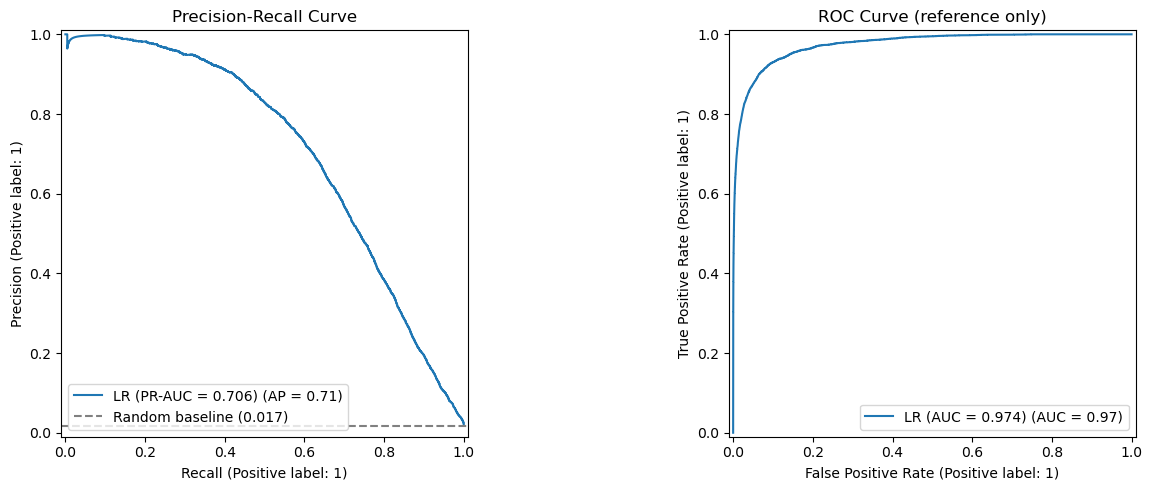

In [53]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba, ax = axes[0], name = f"LR (PR-AUC = {pr_auc:.3f})")
axes[0].axhline(y_test.mean(), color = "gray", linestyle = "--",
                label = f"Random baseline ({y_test.mean():.3f})")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend()

RocCurveDisplay.from_predictions(
    y_test, y_proba, ax = axes[1], name = f"LR (AUC = {roc_auc:.3f})")
axes[1].set_title("ROC Curve (reference only)")
plt.tight_layout()

In [54]:
precisions, recalls, thresholds =  precision_recall_curve(y_test, y_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-10)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal threshold (max F1): {best_threshold: .3f}")
print(f"F1 at optimal threshold: {best_f1: .4f}")

Optimal threshold (max F1):  0.970
F1 at optimal threshold:  0.6593


### Threshold comparison

The classification report above used the **default 0.5 threshold**, which is misleading here — because `class_weight="balanced"` trains the model to be aggressive about flagging fraud, the predicted probabilities skew high, resulting in low precision (0.18) at 0.5.

The optimal threshold found above (0.970) corrects for this. The report below reflects how the model should actually be evaluated and deployed.

In [55]:
y_pred_opt = (y_proba >= best_threshold).astype(int)
print(f"\nAt optimal threshold ({best_threshold:.3f}):")
print(classification_report(y_test, y_pred_opt, target_names=["Legit", "Fraud"]))


At optimal threshold (0.970):
              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99    328190
       Fraud       0.70      0.62      0.66      5725

    accuracy                           0.99    333915
   macro avg       0.85      0.81      0.83    333915
weighted avg       0.99      0.99      0.99    333915



### Feature coefficients

In [56]:
coef_df = pd.DataFrame({
    "feature": FEATURE_COLS_LINEAR,
    "coefficient": lr.coef_[0]
}).sort_values("coefficient", ascending = False)

print("Top 10 features increasing fraud probability:")
print(coef_df.head(10).to_string(index = False))

print("\nTop 10 features decreasing fraud probability:")
print(coef_df.tail(10).to_string(index = False))

Top 10 features increasing fraud probability:
                        feature  coefficient
                  ip_risk_score     2.108110
                   card_present     1.361284
                     log_amount     1.235324
      merchant_category_grocery     0.683946
               is_high_velocity     0.680764
   merchant_category_restaurant     0.643566
  merchant_category_gas_station     0.471059
     merchant_category_pharmacy     0.467750
merchant_category_online_retail     0.354782
     merchant_category_clothing     0.287555

Top 10 features decreasing fraud probability:
                         feature  coefficient
   merchant_category_electronics    -0.076992
merchant_category_money_transfer    -0.098168
                     pct_foreign    -0.108558
                         has_2fa    -0.121591
        merchant_category_crypto    -0.132361
        merchant_category_travel    -0.173661
         device_type_web_browser    -0.660875
                    device_known    -0.74217

### Summary

In [57]:
print(f"BASELINE TO BEAT - PR-AUC: {pr_auc:.4f}")

BASELINE TO BEAT - PR-AUC: 0.7064


### Save Predictions


In [58]:
pd.DataFrame({
    "y_test":   y_test.values,
    "lr_proba": y_proba
}).to_csv(data_dir / "predictions_lr.csv", index=False)

print("Saved predictions_lr.csv")


Saved predictions_lr.csv
